In [53]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


sns.set_theme(style='whitegrid',palette='muted')

db_path = Path('../data/db/blue_mf.db')
con = sqlite3.connect(db_path)

print('connected')

connected


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9452\2368026008.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_aum,x='max_aum',y='fund_house',palette='Blues_r')


saved


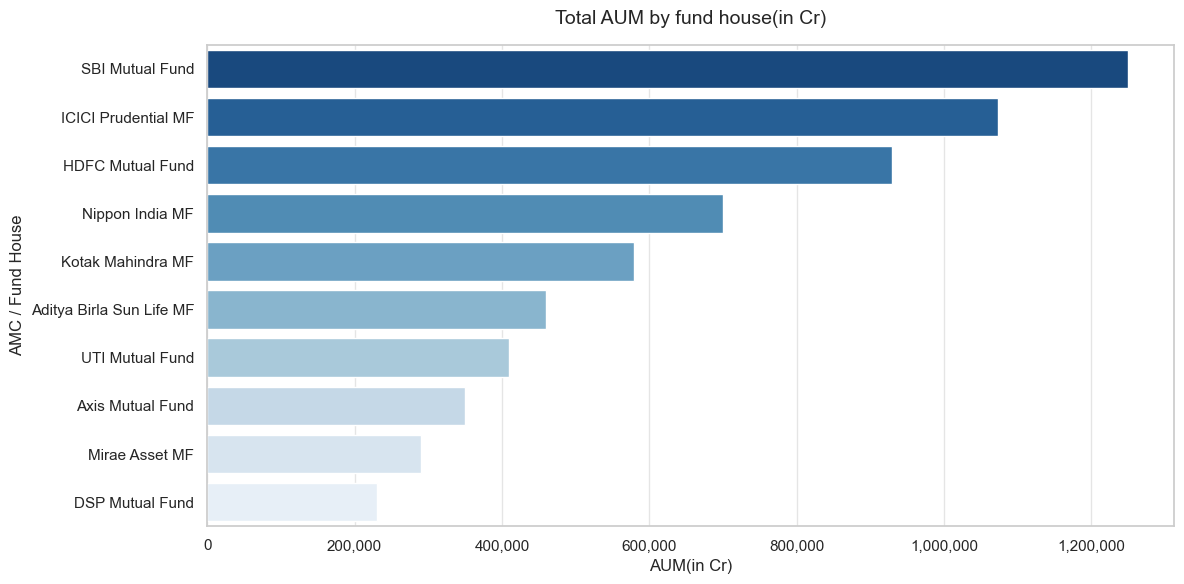

In [54]:
query = """
     SELECT fund_house, MAX(aum_crore) as max_aum
     FROM fact_aum
     GROUP BY fund_house
     ORDER BY max_aum DESC
"""

df_aum = pd.read_sql(query,con)

plt.figure(figsize=(12,6))
ax = sns.barplot(data=df_aum,x='max_aum',y='fund_house',palette='Blues_r')

plt.title('Total AUM by fund house(in Cr)',fontsize=14,pad = 15)
plt.xlabel('AUM(in Cr)',fontsize=12)
plt.ylabel('AMC / Fund House',fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))

plt.tight_layout()

plt.savefig('../reports/images/total_aum_by_fund_house.png', bbox_inches='tight')
print('saved')
plt.show()



In [55]:
#sip growth trend
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

img_dir = Path('../reports/images')
img_dir.mkdir(parents=True, exist_ok=True)



query = """
SELECT strftime('%Y-%m',transaction_date) AS month,SUM(amount_inr) as total_sip_vol
FROM fact_transactions
WHERE transaction_type = 'Sip'
GROUP BY month
ORDER BY month
"""


df_sip = pd.read_sql(query,con)


fig = px.line(
    df_sip,
    x='month',
    y='total_sip_vol',
    title='Monthly SIP Inflows (Jan 2022 - Dec 2025)',
    labels={'month': 'Timeline', 'total_sip_vol': 'Total SIP Volume (₹)'},
    template='plotly_white'
)

max_row = df_sip.loc[df_sip['total_sip_vol'].idxmax()]
peak_month = max_row['month']
peak_value = max_row['total_sip_vol']

fig.add_annotation(
    x=peak_month,
    y=peak_value,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowcolor="red",
    font=dict(size=14, color="red"),
    ay=-40
)

fig.update_traces(line=dict(color='teal', width=3))
fig.show()

fig.write_image(img_dir / 'sip_inflow_trend.png')
print("image saved")

image saved


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9452\997177184.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip,x='age_group',y='amount_inr',order=age_order,ax=axes[1],palette='crest')


saved


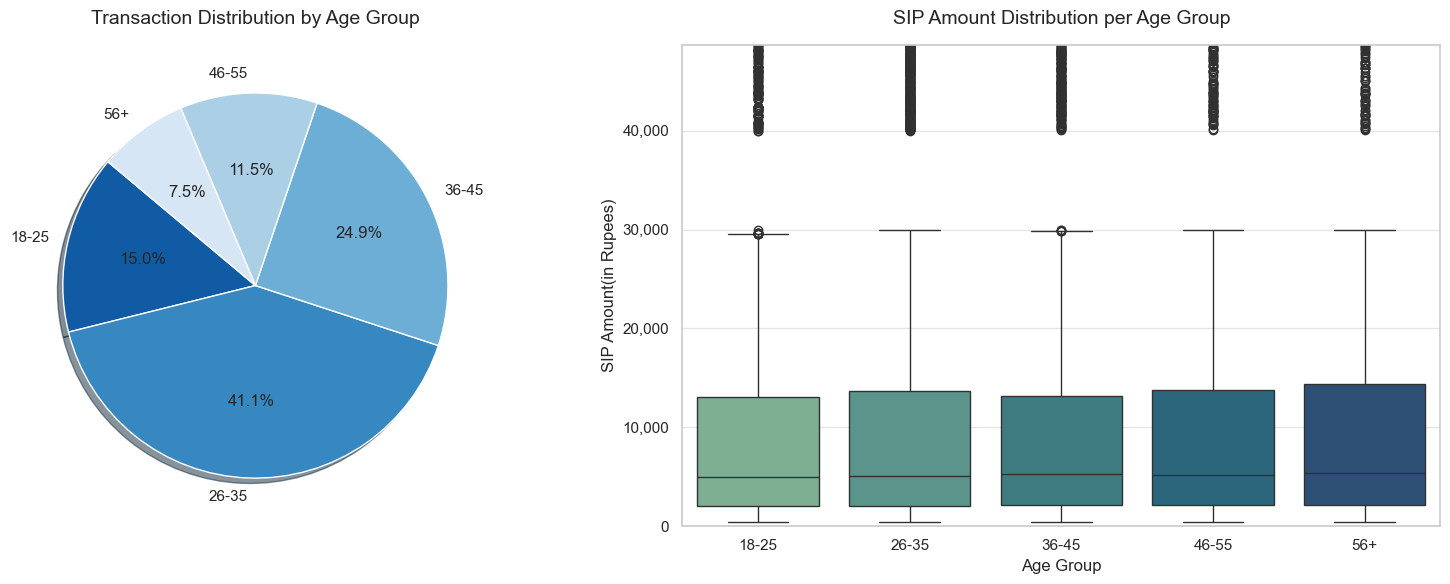

In [56]:
import matplotlib.ticker as ticker
# distribution of investors by age

query_age = """
SELECT age_group,COUNT(*) as tx_count
FROM fact_transactions
GROUP BY age_group
order by age_group
"""

df_age = pd.read_sql(query_age,con)

# raw sip box plot
query_sip = """
SELECT age_group,amount_inr
FROM fact_transactions
WHERE transaction_type = 'Sip'
"""

df_sip = pd.read_sql(query_sip,con)

fig,axes = plt.subplots(1,2,figsize=(16,6))
colors = sns.color_palette("Blues_r",len(df_age))
axes[0].pie(df_age['tx_count'],labels=df_age['age_group'],autopct='%1.1f%%',startangle=140,colors=colors,shadow=True,wedgeprops={'edgecolor':'white'})
axes[0].set_title('Transaction Distribution by Age Group',fontsize=14,pad=15)

age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=df_sip,x='age_group',y='amount_inr',order=age_order,ax=axes[1],palette='crest')
axes[1].set_title('SIP Amount Distribution per Age Group',fontsize=14,pad=15)
axes[1].set_xlabel('Age Group',fontsize=12)
axes[1].set_ylabel('SIP Amount(in Rupees)',fontsize=12)

y_cap = df_sip['amount_inr'].quantile(0.95)
axes[1].set_ylim(0,y_cap)

axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos:f'{int(x):,}'))
plt.tight_layout()

plt.savefig('../reports/images/dist_of_investor_by_age.png', bbox_inches='tight')
print('saved')
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9452\458787102.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_state,x='total_volume',y='state',ax=axes[0],palette='viridis')


saved


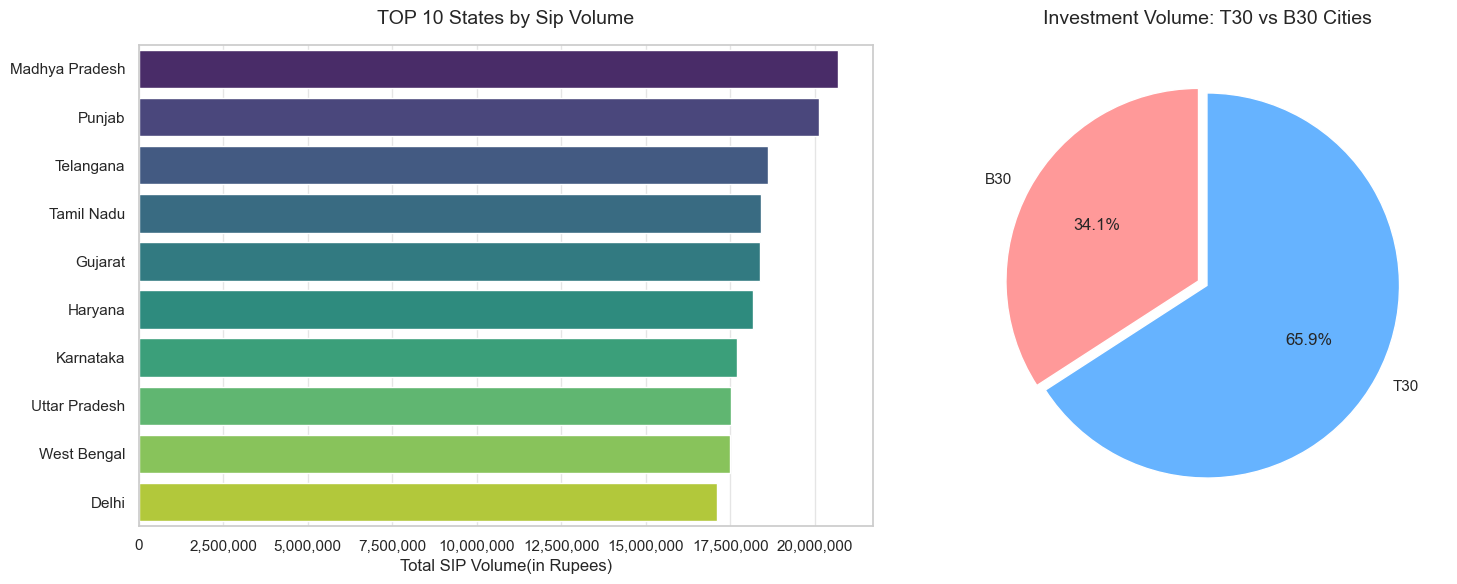

In [57]:
#top 10 states by total_sip_vol

query_state = """
SELECT state,SUM(amount_inr) as total_volume
FROM fact_transactions
where transaction_type = 'Sip'
GROUP BY state
order by total_volume DESC
LIMIT 10
"""

df_state = pd.read_sql(query_state,con)

#T30 vs B30 total_investment_vol
query_tier = """
SELECT city_tier,SUM(amount_inr) as total_volume
FROM fact_transactions
GROUP BY city_tier
"""

df_tier = pd.read_sql(query_tier,con)
fig,axes = plt.subplots(1,2,figsize=(16,6))

sns.barplot(data=df_state,x='total_volume',y='state',ax=axes[0],palette='viridis')
axes[0].set_title('TOP 10 States by Sip Volume',fontsize=14,pad=15)
axes[0].set_xlabel('Total SIP Volume(in Rupees)',fontsize=12)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,loc: "{:,}".format(int(x))))

axes[1].pie(df_tier['total_volume'],labels=df_tier['city_tier'],autopct='%1.1f%%',startangle=90,colors=['#ff9999','#66b3ff'],explode=(0.05,0))
axes[1].set_title('Investment Volume: T30 vs B30 Cities',fontsize=14,pad=15)

plt.tight_layout()

plt.savefig('../reports/images/top_10_states_by_total_sip_vol.png', bbox_inches='tight')
print('saved')
plt.show()


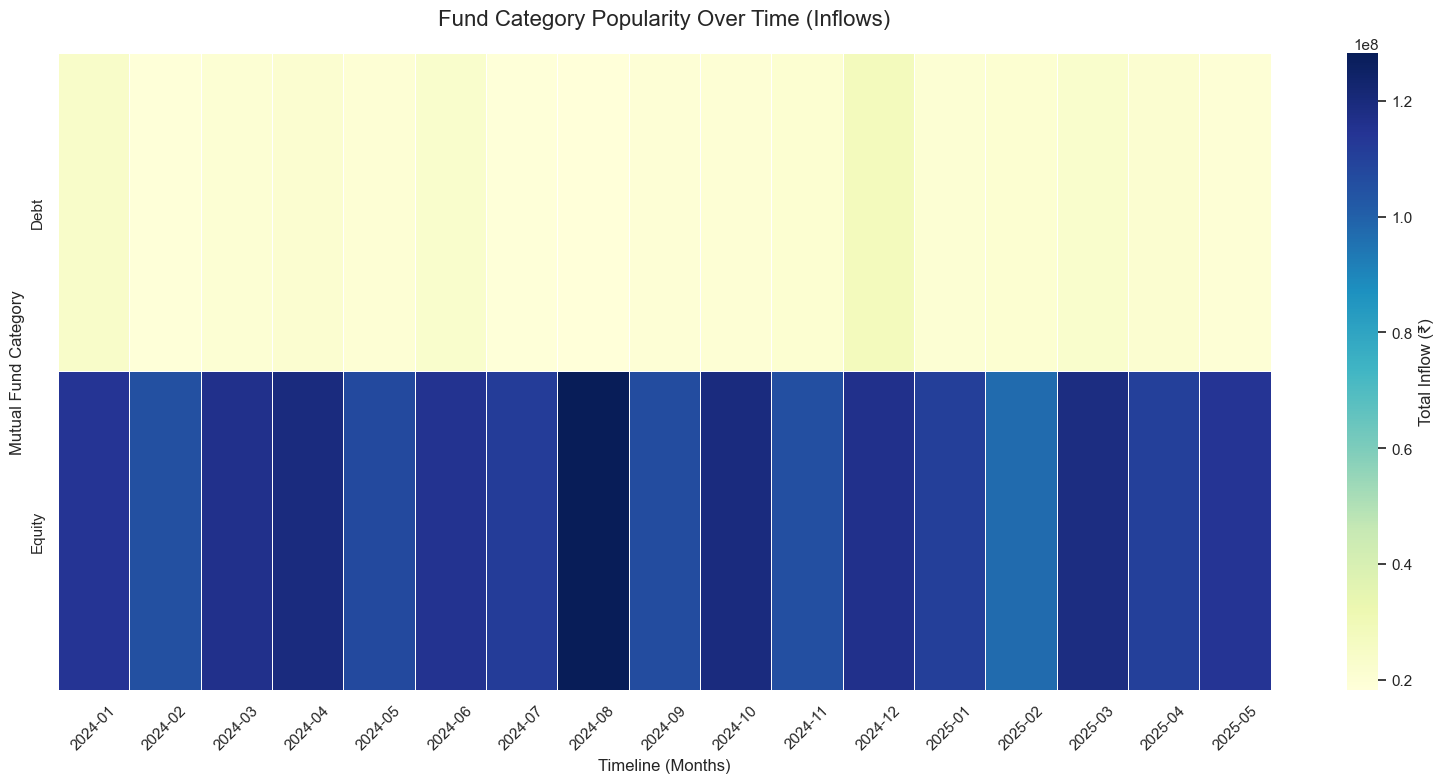

heatmap saved


In [58]:
# Query: Join transactions with the fund master to get categories, and aggregate by month
query = """
    SELECT
        strftime('%Y-%m', t.transaction_date) AS month,
        d.category,
        SUM(t.amount_inr) as total_inflow
    FROM fact_transactions t
    JOIN dim_fund d ON t.amfi_code = d.amfi_code
    WHERE t.transaction_type IN ('Sip', 'Lumpsum')
    GROUP BY month, d.category
"""
df = pd.read_sql(query, con)

heatmap_data = df.pivot(index='category', columns='month', values='total_inflow')

plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Total Inflow (₹)'}
)

plt.title('Fund Category Popularity Over Time (Inflows)', fontsize=16, pad=20)
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Mutual Fund Category', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


ax.figure.savefig(img_dir / 'category_inflow_heatmap.png')
print('heatmap saved')

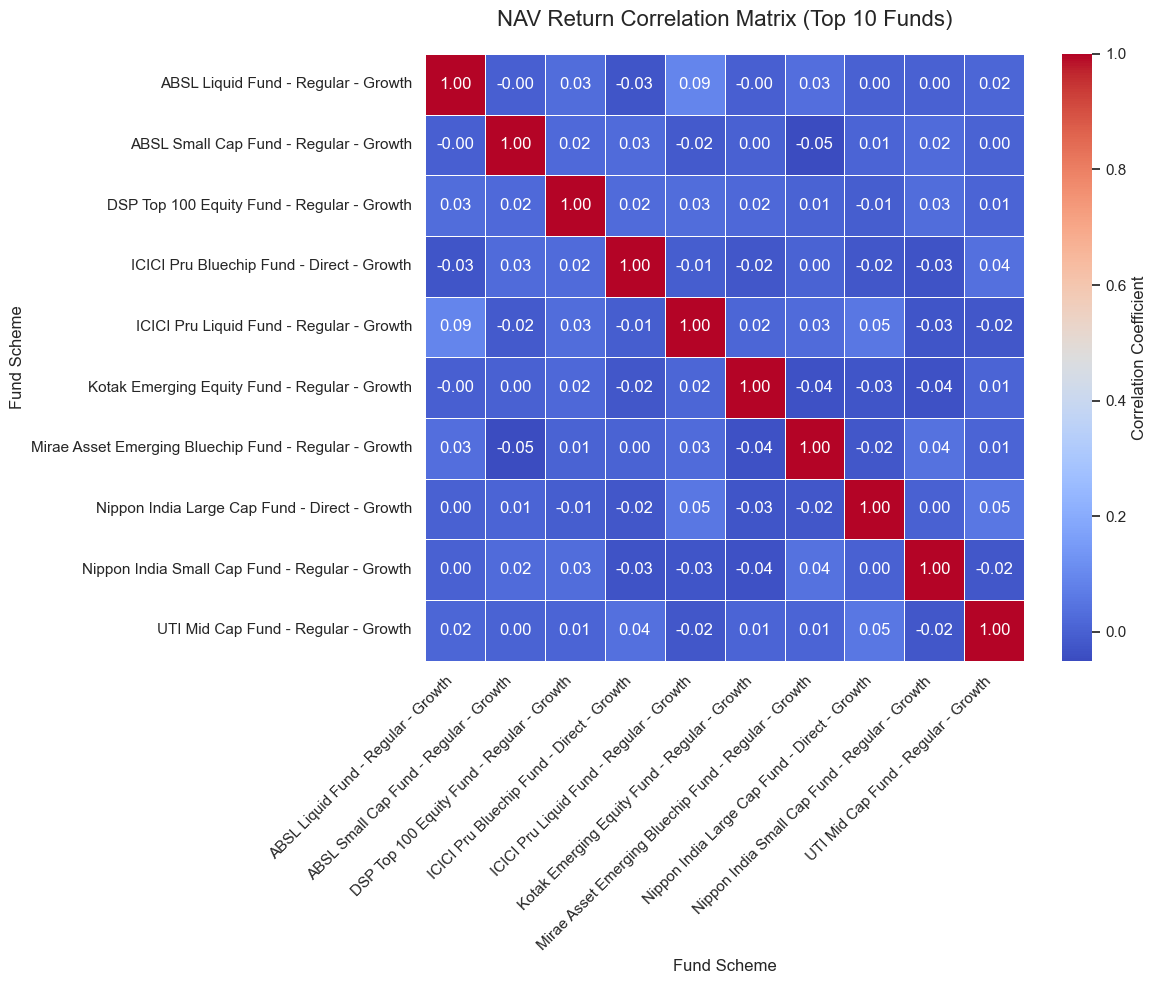

corr matrix saved


In [59]:
# 1. Query: Get the daily NAV for 10 selected funds (we will pick the top 10 by AUM)
query = """
    SELECT n.date, f.scheme_name, n.nav
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    WHERE n.amfi_code IN (
        SELECT amfi_code FROM fact_performance ORDER BY aum_crore DESC LIMIT 10
    )
"""
df_nav = pd.read_sql(query, con)

nav_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')

daily_returns = nav_pivot.pct_change().dropna()
correlation_matrix = daily_returns.corr()


plt.figure(figsize=(12, 10))

ax_corr = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('NAV Return Correlation Matrix (Top 10 Funds)', fontsize=16, pad=20)
plt.xlabel('Fund Scheme', fontsize=12)
plt.ylabel('Fund Scheme', fontsize=12)


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

ax_corr.figure.savefig(img_dir / 'nav_correlation_matrix.png')
print("corr matrix saved")

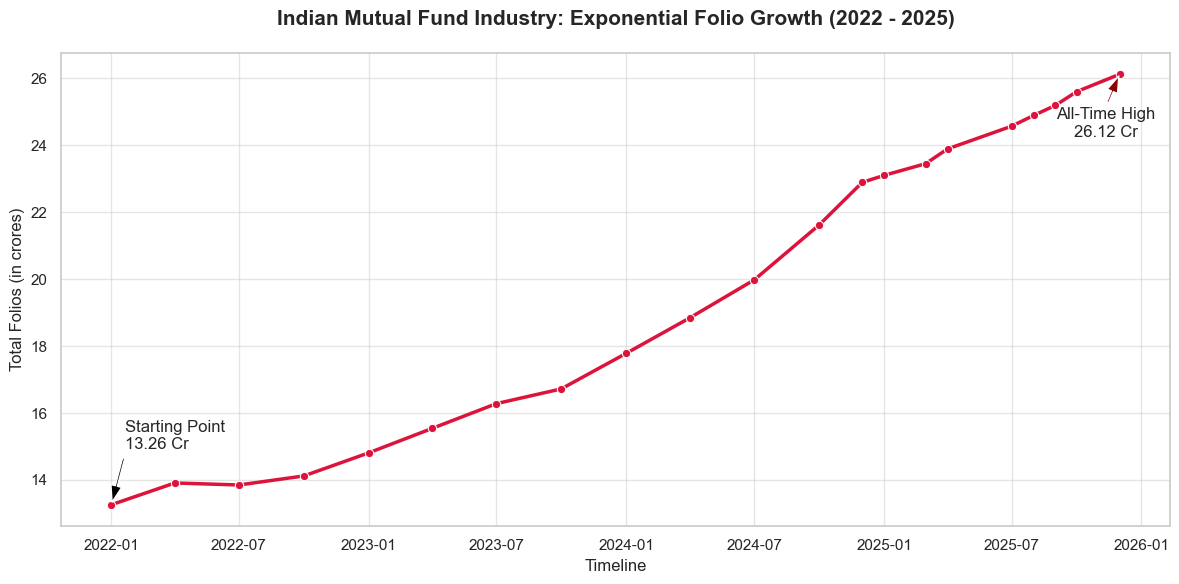

growth chart saved


In [60]:
# Query: Fetch historical industry folio counts

query_folio = "SELECT * FROM fact_industry_folio ORDER BY month"

df_folio = pd.read_sql(query_folio, con)


df_folio['month'] = pd.to_datetime(df_folio['month'])

plt.figure(figsize=(12, 6))
ax_folio = sns.lineplot(data=df_folio, x='month', y='total_folios_crore', marker='o', color='crimson', linewidth=2.5)

plt.title('Indian Mutual Fund Industry: Exponential Folio Growth (2022 - 2025)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Folios (in crores)', fontsize=12)

start_date = df_folio['month'].min()
end_date = df_folio['month'].max()
start_val = df_folio['total_folios_crore'].iloc[0]
end_val = df_folio['total_folios_crore'].iloc[-1]

plt.annotate(
    f'Starting Point\n{start_val} Cr',
    xy=(start_date, start_val),
    xytext=(10, 40),
    textcoords='offset points',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8)
)

plt.annotate(
    f'All-Time High\n{end_val} Cr',
    xy=(end_date, end_val),
    xytext=(-10, -45),
    textcoords='offset points',
    ha='center',
    arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=8)
)
plt.tight_layout()
plt.show()

ax_folio.figure.savefig(img_dir / 'folio_count_growth.png')
print("growth chart saved")

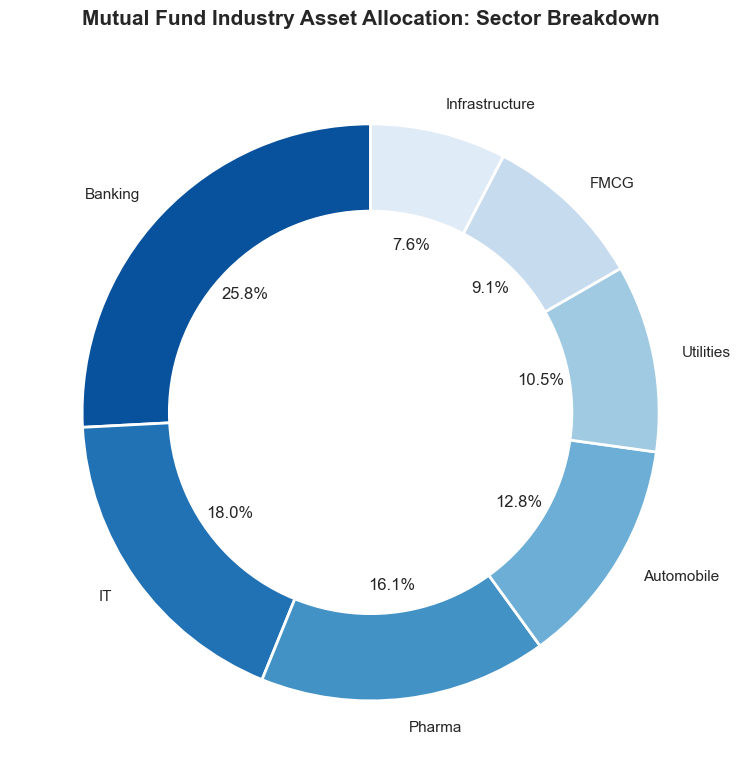

donut saved


In [61]:
# Query: Get aggregated weights per sector across equity funds
query_sector = """
    SELECT sector, SUM(weight_pct) as total_weight
    FROM fact_portfolio_holdings
    WHERE sector IS NOT NULL AND sector != ''
    GROUP BY sector
    ORDER BY total_weight DESC
    LIMIT 7
"""
df_sector = pd.read_sql(query_sector, con)

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Blues_r', len(df_sector))

plt.pie(df_sector['total_weight'], labels=df_sector['sector'],autopct='%1.1f%%',startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Mutual Fund Industry Asset Allocation: Sector Breakdown', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(img_dir / 'sector_allocation_donut.png')
print("donut saved")

saved


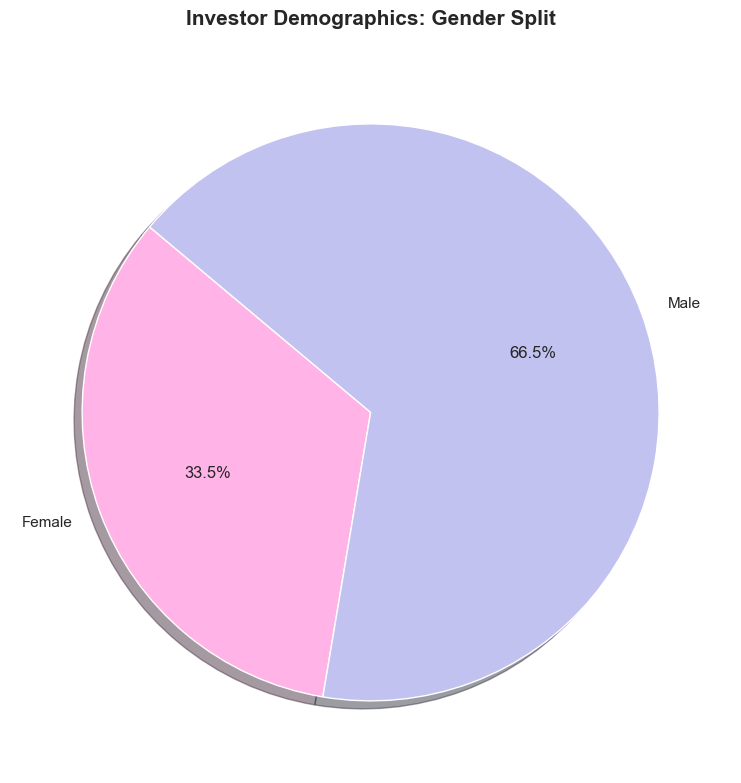

In [63]:
# Query: Extract the gender distribution from the transactions table
query_gender = """
    SELECT gender, COUNT(*) as transaction_count
    FROM fact_transactions
    WHERE gender IS NOT NULL
    GROUP BY gender
"""
df_gender = pd.read_sql(query_gender,con)


plt.figure(figsize=(8, 8))


colors = ['#ffb3e6', '#c2c2f0', '#99ff99']
ax_gender = plt.pie(df_gender['transaction_count'], labels=df_gender['gender'],autopct='%1.1f%%',startangle=140, colors=colors,shadow=True,wedgeprops={'edgecolor': 'white'})

plt.title('Investor Demographics: Gender Split',fontsize=15, fontweight='bold',pad=20)
plt.tight_layout()
plt.savefig(img_dir / 'gender_split_pie.png', bbox_inches='tight')
print('saved')
plt.show()


## Executive Summary: Key EDA Findings

1. **Gender Disparity in Investing:** The investor base shows a significant gender gap, with male investors dominating the distribution at 66.5% compared to female investors at 33.5%. *(Ref: Investor Demographics: Gender Split Pie Chart)*
2. **Core Millennial Dominance:** The 26-35 age bracket is the driving force of the market, accounting for a massive 41.1% of all transactions. Together with the 36-45 bracket, they make up 66% of the total transaction volume. *(Ref: Transaction Distribution by Age Group)*
3. **Age vs. Investment Capacity:** While younger investors (18-25) represent a solid 15% of transaction volume, their median SIP amounts are the lowest. Conversely, the older demographics (46-55 and 56+) display higher median investment capacities. *(Ref: SIP Amount Distribution per Age Group)*
4. **Equity Overwhelming Debt:** Capital allocation shows an extreme bias toward Equity funds over Debt funds. Month over month, Equity inflows dwarf Debt inflows, with a distinct spike in capital deployment observed in August 2024. *(Ref: Fund Category Popularity Over Time)*
5. **Sector Concentration Risk:** Mutual fund asset allocation is heavily anchored in the Banking sector, which consumes over a quarter (25.8%) of all holdings. *(Ref: Mutual Fund Industry Asset Allocation)*
6. **Defensive Sector Hedging:** To counterbalance the heavy financial sector exposure, funds are utilizing IT (18.0%) and Pharma (16.1%) as their primary secondary and tertiary sector bets. *(Ref: Mutual Fund Industry Asset Allocation)*
7. **Zero-Correlation Portfolios:** Surprisingly, a pairwise analysis of the top 10 funds reveals correlation coefficients resting almost entirely at or near 0.00. This indicates highly independent fund movements and excellent diversification potential for investors holding multiple funds. *(Ref: NAV Return Correlation Matrix)*
8. **Relentless Folio Expansion:** The industry experienced near-perfect exponential growth in user adoption, practically doubling from 13.26 Crore folios in Jan 2022 to 26.12 Crore by the close of the timeline. *(Ref: Exponential Folio Growth)*
9. **High-Volatility SIP Behaviors:** Total monthly SIP volumes exhibit sharp, volatile swings—such as the massive drop near January 2025 down to ~11.4M, immediately followed by an aggressive V-shaped recovery spiking toward 14M. *(Ref: Monthly SIP Inflows)*